In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [3]:
# ==========================================
# PART A: DATA UNDERSTANDING & PREPROCESSING
# ==========================================

# NOTE: Replace these paths with your actual local/Colab directory paths
TRAIN_DIR = os.path.join(path, "seg_train", "seg_train")
TEST_DIR = os.path.join(path, "seg_test", "seg_test")

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# 1. Understanding Dataset Structure
classes = sorted(os.listdir(TRAIN_DIR))
print(f"Detected Classes ({len(classes)}): {classes}")

Detected Classes (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [5]:

# 2. Data Augmentation & Normalization
# Creating a training generator with random transformations to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1.0/255,          # Normalize pixel values from [0, 255] to [0, 1]
    rotation_range=20,        # Randomly rotate images up to 20 degrees
    width_shift_range=0.1,    # Randomly shift horizontally
    height_shift_range=0.1,   # Randomly shift vertically
    shear_range=0.1,          # Apply shear transformations
    zoom_range=0.1,           # Randomly zoom inside pictures
    horizontal_flip=True,     # Flip images horizontally
    fill_mode='nearest',
    validation_split=0.2      # Splitting 20% of training data for validation
)

# Test data should only be normalized (Never augmented!)
test_datagen = ImageDataGenerator(rescale=1.0/255)

In [7]:
# 3. Splitting Dataset into Train, Validation, and Test
print("\n--- Loading Datasets ---")

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False             # Keep False to cleanly map predictions to true labels
)



--- Loading Datasets ---
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [8]:
# PART B: CNN MODEL DEVELOPMENT
# ==========================================

# 4. Building the CNN from Scratch
model = models.Sequential([
    # Layer 1: Input expects (150, 150, 3) -> 3 represents RGB channels
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    # Layer 2: Deeper feature extraction
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer 3: Minimum required 3rd convolutional block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer 4: Extra layer to handle spatial size reduction
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flattening 2D feature maps into a 1D vector
    layers.Flatten(),

    # Fully Connected Layer with Regularization (Dropout)
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Drops 50% of activations to combat overfitting

    # Output layer: 6 units corresponding to the 6 natural scene classes
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,455,686 (13.18 MB)

 Trainable params: 3,455,686 (13.18 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting Model Training ---
Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.4647 - loss: 1.2969

351/351 ━━━━━━━━━━━━━━━━━━━━ 153s 415ms/step - accuracy: 0.5459 - loss: 1.1239 - val_accuracy: 0.6031 - val_loss: 0.9996
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.6293 - loss: 0.9386

351/351 ━━━━━━━━━━━━━━━━━━━━ 94s 268ms/step - accuracy: 0.6589 - loss: 0.8967 - val_accuracy: 0.6676 - val_loss: 0.8651
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.7167 - loss: 0.7741

351/351 ━━━━━━━━━━━━━━━━━━━━ 93s 265ms/step - accuracy: 0.7288 - loss: 0.7476 - val_accuracy: 0.7639 - val_loss: 0.6657
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7506 - loss: 0.7006

351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 270ms/step - accuracy: 0.7588 - loss: 0.6738 - val_accuracy: 0.7718 - val_loss: 0.6359
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 92s 263ms/step - accuracy: 0.7722 - loss: 0.6321 - val_accuracy: 0.7329 - val_loss: 0.7473
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.7755 - loss: 0.6188

...

351/351 ━━━━━━━━━━━━━━━━━━━━ 90s 257ms/step - accuracy: 0.8011 - loss: 0.5568 - val_accuracy: 0.8217 - val_loss: 0.5139
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 90s 257ms/step - accuracy: 0.8096 - loss: 0.5311 - val_accuracy: 0.8203 - val_loss: 0.5154
Epoch 9/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 92s 263ms/step - accuracy: 0.8114 - loss: 0.5269 - val_accuracy: 0.8217 - val_loss: 0.5300
Epoch 10/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.8220 - loss: 0.5079

351/351 ━━━━━━━━━━━━━━━━━━━━ 92s 262ms/step - accuracy: 0.8186 - loss: 0.5043 - val_accuracy: 0.8213 - val_loss: 0.4984
Epoch 11/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 91s 260ms/step - accuracy: 0.8289 - loss: 0.4887 - val_accuracy: 0.8281 - val_loss: 0.5042
Epoch 12/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.8333 - loss: 0.4688

351/351 ━━━━━━━━━━━━━━━━━━━━ 93s 265ms/step - accuracy: 0.8354 - loss: 0.4645 - val_accuracy: 0.8381 - val_loss: 0.4499
Epoch 13/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 92s 261ms/step - accuracy: 0.8383 - loss: 0.4564 - val_accuracy: 0.8406 - val_loss: 0.4609
Epoch 14/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.8383 - loss: 0.4405

351/351 ━━━━━━━━━━━━━━━━━━━━ 93s 264ms/step - accuracy: 0.8350 - loss: 0.4459 - val_accuracy: 0.8431 - val_loss: 0.4281
Epoch 15/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 93s 264ms/step - accuracy: 0.8421 - loss: 0.4368 - val_accuracy: 0.8452 - val_loss: 0.4485
Epoch 16/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 92s 262ms/step - accuracy: 0.8492 - loss: 0.4169 - val_accuracy: 0.8363 - val_loss: 0.4581
Epoch 17/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.8511 - loss: 0.4142

351/351 ━━━━━━━━━━━━━━━━━━━━ 93s 264ms/step - accuracy: 0.8527 - loss: 0.4142 - val_accuracy: 0.8559 - val_loss: 0.4254
Epoch 18/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 92s 262ms/step - accuracy: 0.8579 - loss: 0.3925 - val_accuracy: 0.8484 - val_loss: 0.4317
Epoch 19/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 91s 260ms/step - accuracy: 0.8639 - loss: 0.3912 - val_accuracy: 0.8538 - val_loss: 0.4320
Epoch 20/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 93s 264ms/step - accuracy: 0.8576 - loss: 0.3971 - val_accuracy: 0.8466 - val_loss: 0.4417
Epoch 21/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 91s 259ms/step - accuracy: 0.8642 - loss: 0.3768 - val_accuracy: 0.8399 - val_loss: 0.5082
Epoch 22/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 91s 258ms/step - accuracy: 0.8651 - loss: 0.3726 - val_accuracy: 0.8392 - val_loss: 0.4449


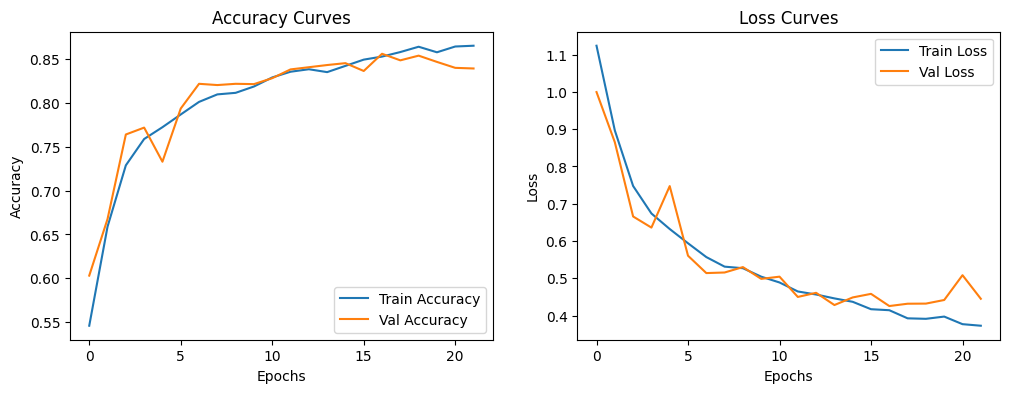

In [9]:
# 5. Callbacks & Model Training
# Early stopping ensures training stops when validation loss plateaus
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_cnn_model.h5', monitor='val_loss', save_best_only=True)
]

print("\n--- Starting Model Training ---")
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=callbacks
)

# Plot Training vs Validation Performance Curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
#PART C: EVALUATION & INTERPRETATION
# ==========================================

# 6. Evaluate on Test Set
print("\n--- Evaluating on Test Set ---")
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Generate predictions for advanced metrics
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

# Precision, Recall, F1-Score
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))



--- Evaluating on Test Set ---
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.8550 - loss: 0.4154
Test Accuracy: 85.50%
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       0.82      0.90      0.86       437
      forest       0.93      0.98      0.95       474
     glacier       0.85      0.76      0.81       553
    mountain       0.83      0.77      0.80       525
         sea       0.80      0.92      0.85       510
      street       0.91      0.82      0.87       501

    accuracy                           0.85      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.85      0.85      3000



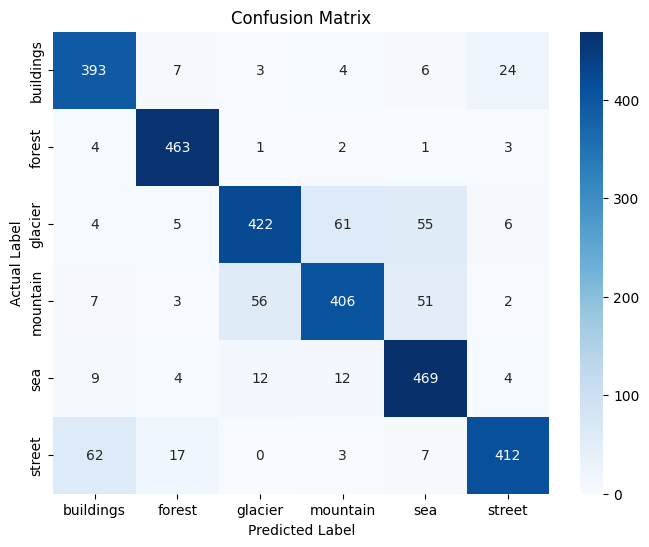

In [12]:
# Confusion Matrix Visual Map
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

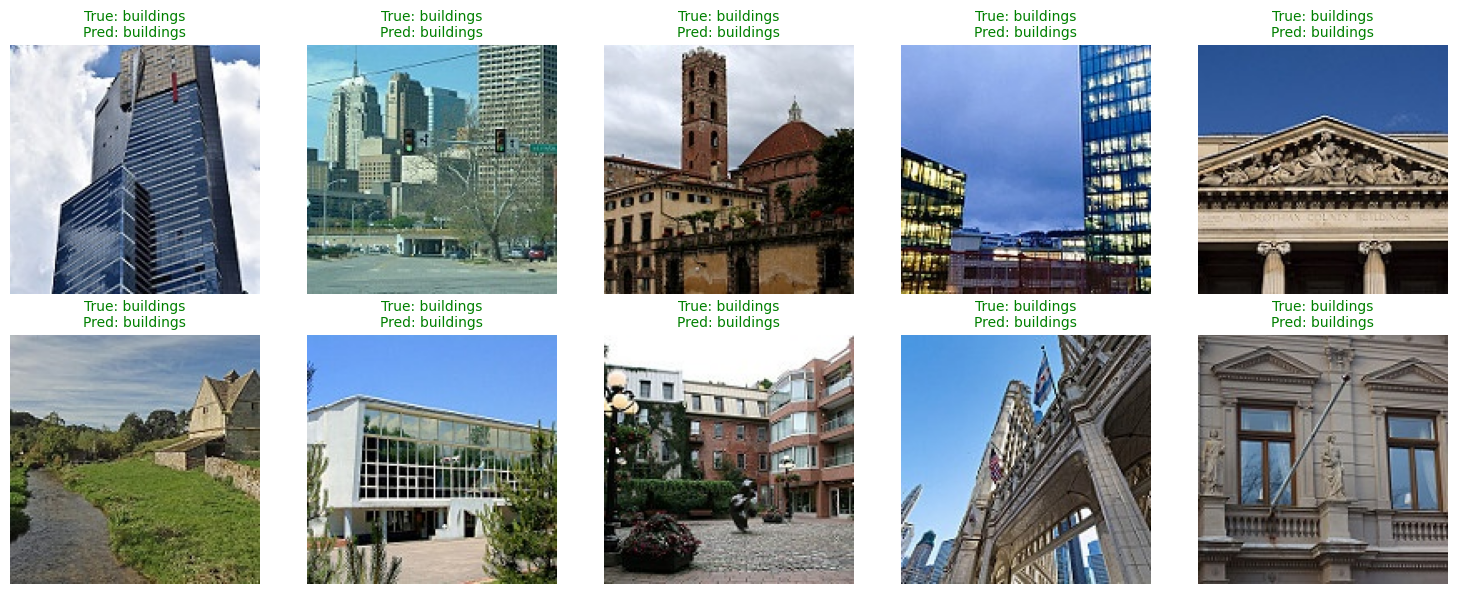

In [13]:
# 7. Visualizing 10 Random Predictions
plt.figure(figsize=(15, 6))
test_images, test_labels = next(test_generator) # pull a batch of images

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i])

    # Grab truth and prediction index values
    true_idx = np.argmax(test_labels[i])

    # Run the single image through prediction pipeline
    single_img = np.expand_dims(test_images[i], axis=0)
    pred_idx = np.argmax(model.predict(single_img, verbose=0))

    color = 'green' if true_idx == pred_idx else 'red'
    plt.title(f"True: {classes[true_idx]}\nPred: {classes[pred_idx]}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()